# Funcionalidades básicas del paquete `stmeasures`

A continuación se muestra un breve ejemplo del uso del paquete desarrollado

## Instalación

La instalación se hace vía `pip`:

In [1]:
pip install stmeasures

  Using cached stmeasures-0.0.1.1-py3-none-any.whl.metadata (5.0 kB)
Using cached stmeasures-0.0.1.1-py3-none-any.whl (63 kB)
Note: you may need to restart the kernel to use updated packages.


## Uso

Una vez instalado el paquete se pueden hacer uso de sus módulos principales.

In [2]:
import stmeasures

### Módulo de lectura

Para leer un archivo JSON/GeoJSON se usa la función `read_file`

In [3]:
dataset = stmeasures.read_file('../assets/ECATEPEC.json')

Teniendo cargado nuestro dataset, podemos hacer uso de todas las funciones que los objetos `GeoJSON`, los cuales implementamos, nos permiten realizar.

#### Tamaños

Del dataset y de trayectorias.

In [4]:
len(dataset), len(dataset[4])

(6000, 27)

#### Trayectorias

Obtener una trayectoria dentro del dataset es sencillo gracias a la sobrecarga que se realiza en python con las indexaciones de las trayectorias cargadas dentro del GeoJSON (dataset).

In [5]:
dataset[403][:5]

[(19.604933, -99.070739),
 (19.604913, -99.070745),
 (19.60492, -99.070743),
 (19.604935, -99.070766),
 (19.604935, -99.070766)]

### Módulo de cálculos

Teniendo un dataset con trayectorias cargadas, ahora es posible realizar cualquier cálculo de cualquiera de estas usando las funciones expuestas al usuario final.

In [6]:
# Cálculo de la distancia euclideana de trayectorias de tamaño 10
stmeasures.euclidean_distance(dataset[2222][:4], dataset[2009][:4])

0.12687269296030426

In [7]:
# Cálculo de la distancia Hausdorff entre 2 trayectorias
stmeasures.hausdorff_distance(dataset[2222], dataset[2009])

0.04897899999999922

In [8]:
# Cálculo de la distancia SPAD
stmeasures.distance(dataset[2222], dataset[2009])

0.009391319236762535

#### Cálculo de otros algoritmos implementados

Los algoritmos que se implementaron y se recomiendan utilizar fueron los siguientes:

- Euclideano (`stmeasures.euclidean_distance`)
- Hausdorff (`stmeasures.hausdorff_distance`)
- Frechet (`stmeasures.frechet_distance`)
- LCSS (`stmeasures.lcss_distance`)
- Spatial Assembling Distance (SPAD `stmeasures.spatial_assembling_distance`)

El cual este último es el algoritmo predeterminado que utiliza la función `stmeasures.distance`, sin embargo, otros algoritmos que fueron utilizados y pueden ser utilizados son:

- Dynamic Time Warping (DTW)
- Edit Distance on Real Sequences (ERS)
- Edit Distance with Real Penalty (ERP)

Estos y cualquier algoritmo mencionado en el proyecto pueden ser utilizados a través de la función `stmeasures.distance` de la siguiente forma:

In [9]:
# Uso de SPAD forzado
stmeasures.distance(dataset[2222], dataset[2009], stmeasures.Algorithms.SPAD)

0.009391319236762535

In [10]:
# Uso de DTW forzado
stmeasures.distance(dataset[2222], dataset[2009], stmeasures.Algorithms.DTW)

62.73799377672612

In [11]:
# Uso de ERP forzado
stmeasures.distance(dataset[2222], dataset[2009], stmeasures.Algorithms.ERP)

5101.250311

## Módulo de visualización

Por último para visualizar trayectorias es posible hacer esto con nuestro paquete y otro en conjunto denominado `geojsonio`, por lo que se empieza instalando este a través de `pip`.

In [12]:
pip install geojsonio

  Using cached geojsonio-0.0.3-py3-none-any.whl
Note: you may need to restart the kernel to use updated packages.


In [13]:
import geojsonio

De esta forma podemos hacer uso de las funciones definidas en nuestro módulo de visualización.

In [14]:
trajectories = [dataset[2222], dataset[2009]]
geojsonio.display(stmeasures.geojsonio_contents(trajectories=trajectories, indexes=[2222, 2009]))

'http://geojson.io/#data=data:application/json,%7B%22type%22%3A%20%22FeatureCollection%22%2C%20%22features%22%3A%20%5B%7B%22type%22%3A%20%22Feature%22%2C%20%22geometry%22%3A%20%7B%22type%22%3A%20%22LineString%22%2C%20%22coordinates%22%3A%20%5B%5B-98.992734%2C%2019.618832%5D%2C%20%5B-99.004548%2C%2019.614264%5D%2C%20%5B-99.047076%2C%2019.613419%5D%2C%20%5B-99.064574%2C%2019.617078%5D%5D%7D%2C%20%22properties%22%3A%20%7B%22index%22%3A%202222%2C%20%22stroke%22%3A%20%22%23bceef3%22%2C%20%22stroke-width%22%3A%202%2C%20%22stroke-opacity%22%3A%201%7D%7D%2C%20%7B%22type%22%3A%20%22Feature%22%2C%20%22geometry%22%3A%20%7B%22type%22%3A%20%22LineString%22%2C%20%22coordinates%22%3A%20%5B%5B-99.05861%2C%2019.569154%5D%2C%20%5B-99.058207%2C%2019.569276%5D%2C%20%5B-99.058316%2C%2019.569382%5D%2C%20%5B-99.058312%2C%2019.569317%5D%2C%20%5B-99.058399%2C%2019.569262%5D%2C%20%5B-99.057612%2C%2019.568183%5D%2C%20%5B-99.057103%2C%2019.569044%5D%2C%20%5B-99.053821%2C%2019.569656%5D%2C%20%5B-99.055397%2C%2019.


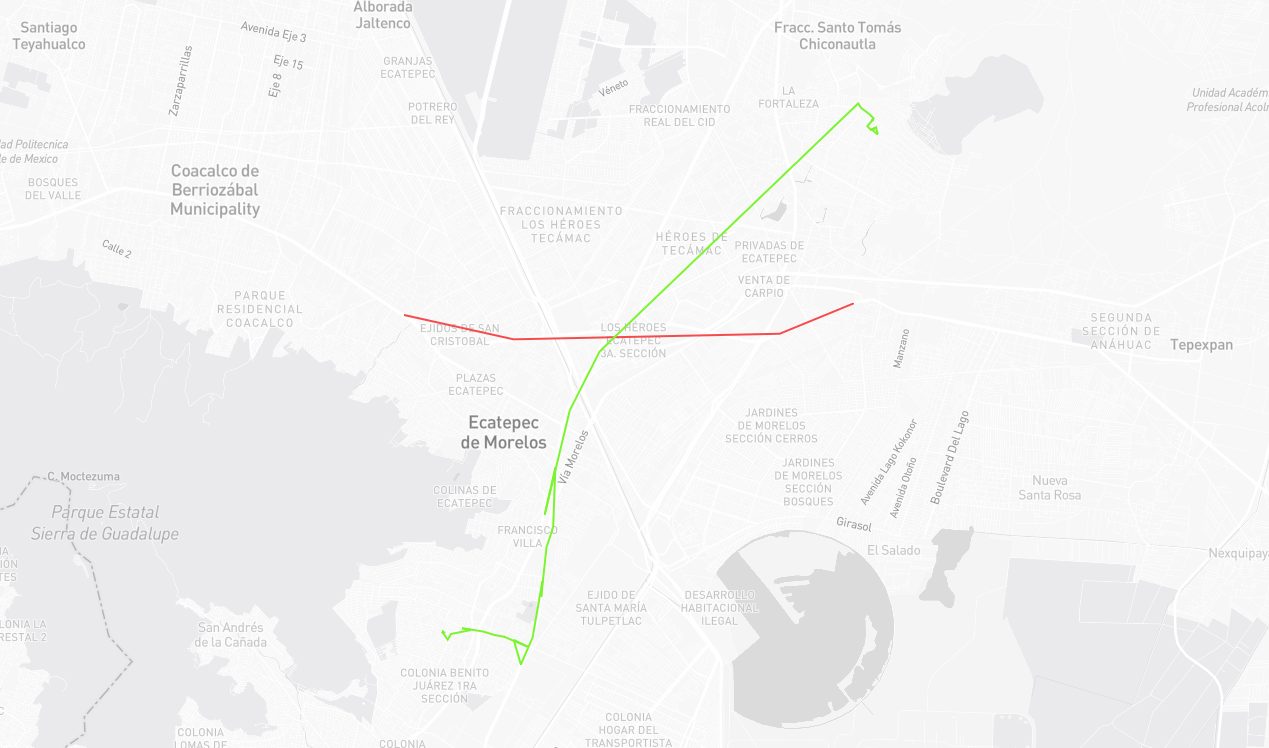